In [1]:
import pandas as pd
import glob
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV


## Import data

In [ ]:
# Reading data
X_train = pd.read_csv('../data/processed/X_train_eda9.csv')
X_test = pd.read_csv('../data/processed/X_test_eda9.csv')
y_train = pd.read_csv('../data/processed/y_train_eda9.csv')
y_test = pd.read_csv('../data/processed/y_test_eda9.csv')

## Creating model and training data - Random Forest

In [17]:
# Instanciar el modelo con valores por defecto
# Solo mantenemos random_state para que los resultados sean repetibles
# y class_weight='balanced' porque los datos de bolsa suelen estar desbalanceados.
simple_rf = RandomForestClassifier(random_state=18, 
                                   class_weight='balanced')

# Entrenar directamente con los datos originales
simple_rf.fit(X_train, y_train)

# Evaluar
y_pred = simple_rf.predict(X_test)
y_probs = simple_rf.predict_proba(X_test)[:, 1]

# RESULTADOS MODELO BASE (SIN OPTIMIZAR)
f'ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}'


'ROC-AUC Score: 0.5076'

In [ ]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
df_report

,precision,recall,f1-score,support
0.0,0.497007,0.495788,0.496397,56268.000000
1.0,0.512132,0.513350,0.512740,58015.000000
accuracy,0.504703,0.504703,0.504703,0.504703
macro avg,0.504569,0.504569,0.504568,114283.000000
weighted avg,0.504685,0.504703,0.504693,114283.000000


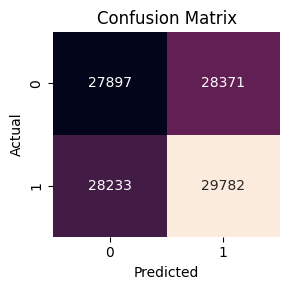

In [19]:
cm1 = confusion_matrix(y_test, y_pred)

# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(cm1)

plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()

## Hiperparametrización

In [20]:
# Optimización con RandomizedSearchCV
# Usamos directamente X_train y y_train (sin escalas)
param_dist = {'n_estimators': [100, 200, 300, 500],
              'max_depth': [None, 10, 20, 30],
              'min_samples_leaf': [50, 100, 200],
              'max_features': ['sqrt', 'log2'],
              'bootstrap': [True]}

random_search = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=18, class_weight='balanced'),
                                   param_distributions=param_dist,
                                   n_iter=20,
                                   cv=5, 
                                   scoring='roc_auc',
                                   n_jobs=-1,
                                   verbose=1,
                                   random_state=18)

# Entrenamos con los datos originales
random_search.fit(X_train, y_train)

# Evaluación del Modelo 
best_rf = random_search.best_estimator_
y_pred_hiper = best_rf.predict(X_test)
y_probs_hiper = best_rf.predict_proba(X_test)[:, 1]

f'Mejor configuración: {random_search.best_params_}'


Fitting 5 folds for each of 20 candidates, totalling 100 fits


"Mejor configuración: {'n_estimators': 500, 'min_samples_leaf': 200, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': True}"

In [21]:
f'ROC-AUC Score: {roc_auc_score(y_test, y_probs_hiper):.4f}'

'ROC-AUC Score: 0.5185'

In [ ]:
report_dict2 = classification_report(y_test, y_pred_hiper, output_dict=True)
df_report2 = pd.DataFrame(report_dict).transpose()

df_report2

,precision,recall,f1-score,support
0.0,0.497007,0.495788,0.496397,56268.000000
1.0,0.512132,0.513350,0.512740,58015.000000
accuracy,0.504703,0.504703,0.504703,0.504703
macro avg,0.504569,0.504569,0.504568,114283.000000
weighted avg,0.504685,0.504703,0.504693,114283.000000


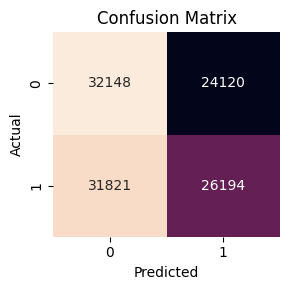

In [ ]:
bank_cm = confusion_matrix(y_test, y_pred_hiper)

# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(bank_cm)

plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - RandomForest')

plt.tight_layout()
plt.show()

## Save model

In [ ]:
# Saving best model
joblib.dump(best_rf, '../models/random-forest-model-final.pkl')